
---

# ***`Feature Scaling : Normalization`***

---

- ***`MinMaxScaler`*** : Output between `0` and `1`.

#### **Import Libraries**

In [2]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import (
    MinMaxScaler,
)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

#### **Load the Dataset**

In [4]:
# Read the CSV file from the specified URL into a DataFrame.
df = pd.read_csv(
    r"https://raw.githubusercontent.com/campusx-official/100-days-of-machine-learning/refs/heads/main/day25-normalization/wine_data.csv",
    header=None,  # Indicate that the CSV file does not have a header row.
    usecols=[0, 1, 2],  # Select only the first three columns (index 0, 1, and 2).
)

# Rename the columns of the DataFrame for better readability.
df.columns = ['Class Label', 'Alcohol', 'Malic Acid']

# Display the first few rows of the DataFrame to verify the data.
df.head()

,Class Label,Alcohol,Malic Acid
0,1,14.23,1.71
1,1,13.20,1.78
2,1,13.16,2.36
3,1,14.37,1.95
4,1,13.24,2.59


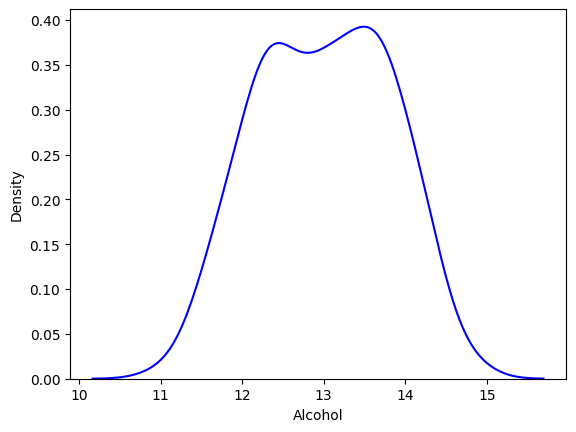

In [8]:
# Create a Kernel Density Estimate (KDE) plot for the 'Alcohol' column in the DataFrame.
# The 'color' parameter specifies the color of the plot (blue in this case).
sns.kdeplot(df['Alcohol'], color='b')

# Display the plot on the screen.
plt.show()

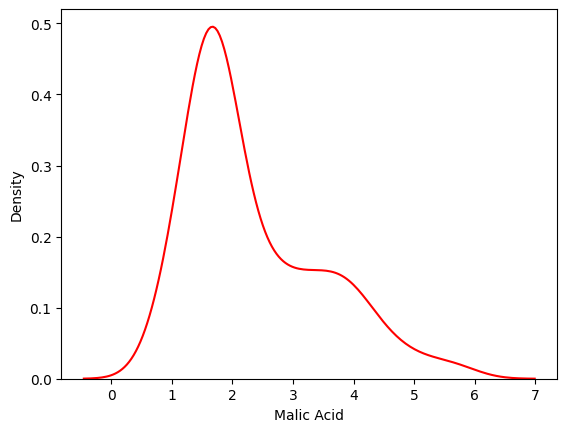

In [9]:
# Create a Kernel Density Estimate (KDE) plot for the 'Malic Acid' column in the DataFrame.
# The 'color' parameter specifies the color of the plot (blue in this case).
sns.kdeplot(df["Malic Acid"], color='r')

# Display the plot on the screen.
plt.show()

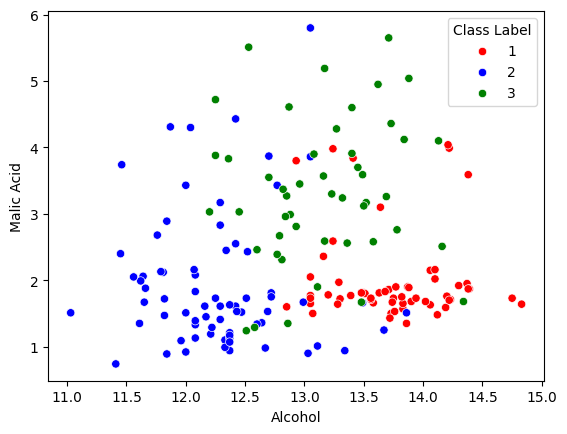

In [15]:
# Create a dictionary to map class labels to specific colors.
color_dict = {1: "red", 3: "green", 2: "blue"}

# Create a scatter plot to visualize the relationship between 'Alcohol' and 'Malic Acid'.
# The 'hue' parameter color-codes the points based on 'Class Label' using the colors defined in color_dict.
sns.scatterplot(x=df['Alcohol'], y=df['Malic Acid'], hue=df['Class Label'], palette=color_dict)

# Display the plot on the screen.
plt.show()

In [16]:
# Split the DataFrame 'df' into training and testing sets.
# 'Class Label' is the target variable, while all other columns are features.

X_train, X_test, y_train, y_test = train_test_split(
    df.drop("Class Label", axis=1),  # Features: all columns except 'Class Label'
    df["Class Label"],                # Target variable: 'Class Label'
    test_size=0.3,                 # 30% of the data will be used for testing
    random_state=0                 # Seed for reproducibility
)

# Output the shapes of the training and testing feature sets
X_train.shape, X_test.shape

((124, 2), (54, 2))

In [17]:
# Create an instance of the MinMaxScaler, which scales features to a range between 0 and 1.
scaler = MinMaxScaler()

# Fit the scaler to the training data (X_train) to compute the minimum and maximum values.
scaler.fit(X_train)

# Transform the training data (X_train) using the fitted scaler to scale the features.
X_train_scaled = scaler.transform(X_train)

# Transform the test data (X_test) using the same scaler to ensure consistent scaling.
X_test_scaled = scaler.transform(X_test)

In [18]:
# Convert the scaled training data back into a DataFrame, using the original column names from X_train.
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns)

# Convert the scaled testing data back into a DataFrame, using the original column names from X_test.
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns)

In [19]:
print("-"*40)
print(f"Before MinMaxScaler Transformation \n\n{X_train.sample(5)}")
print("-"*40)
print(f"After MinMaxScaler Transformation \n\n{X_train_scaled.sample(5)}")
print("-"*40)

----------------------------------------
Before MinMaxScaler Transformation 

     Alcohol  Malic Acid
62     13.67        1.25
118    12.77        3.43
47     13.90        1.68
167    12.82        3.37
27     13.30        1.72
----------------------------------------
After MinMaxScaler Transformation 

      Alcohol  Malic Acid
106  0.543011    0.243697
25   0.279570    0.266807
61   0.860215    0.172269
64   0.900538    0.567227
117  0.510753    0.611345
----------------------------------------


In [21]:
print(np.round(X_train.describe(), 1))

       Alcohol  Malic Acid
count    124.0       124.0
mean      13.0         2.4
std        0.8         1.1
min       11.0         0.9
25%       12.4         1.6
50%       13.0         1.9
75%       13.6         3.2
max       14.8         5.6


In [20]:
# Generate descriptive statistics for the scaled training data.
# The 'describe()' method provides a summary of the central tendency, dispersion, and shape of the dataset's distribution.
# 'np.round(..., 1)' rounds the results to one decimal place for easier readability.
print(np.round(X_train_scaled.describe(), 1))

       Alcohol  Malic Acid
count    124.0       124.0
mean       0.5         0.3
std        0.2         0.2
min        0.0         0.0
25%        0.4         0.2
50%        0.5         0.2
75%        0.7         0.5
max        1.0         1.0


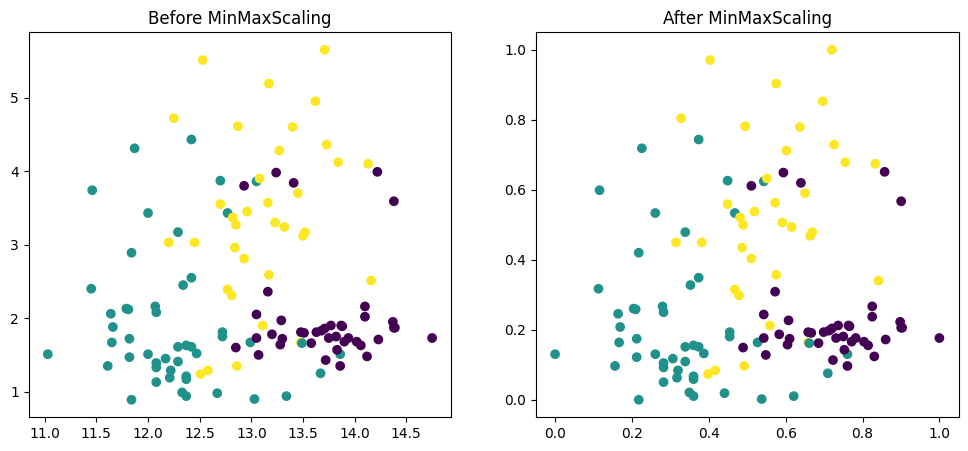

In [24]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Scatter plot of 'Alcohol' vs 'Malic Acid' from the original training data (before scaling).
ax1.scatter(X_train['Alcohol'], X_train["Malic Acid"], c=y_train)
ax1.set_title("Before MinMaxScaling")  # Set the title for the first subplot.

# Scatter plot of 'Alcohol' vs 'Malic Acid' from the scaled training data (after scaling), in red.
ax2.scatter(X_train_scaled['Alcohol'], X_train_scaled['Malic Acid'], c=y_train)
ax2.set_title("After MinMaxScaling")  # Set the title for the second subplot.

# Display the plots.
plt.show()

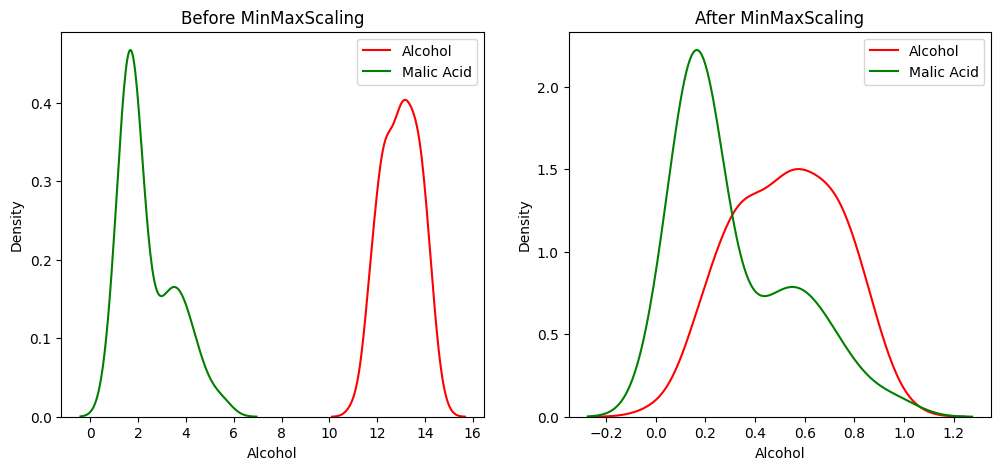

In [27]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Set the title for the first subplot.
ax1.set_title("Before MinMaxScaling")

# Plot the KDE (Kernel Density Estimate) for 'Alcohol' and 'Malic Acid' in the original data.
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol', color='r')  # Added label for clarity
sns.kdeplot(X_train['Malic Acid'], ax=ax1, label='Malic Acid', color='g')  # Added label for clarity
ax1.legend()  # Show legend for the first plot.

# Set the title for the second subplot.
ax2.set_title("After MinMaxScaling")

# Plot the KDE for 'Alcohol' and 'Malic Acid' in the scaled data.
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol', color='r')  # Added label and color for clarity
sns.kdeplot(X_train_scaled['Malic Acid'], ax=ax2, label='Malic Acid', color='g')  # Added label and color for clarity
ax2.legend()  # Show legend for the second plot.

# Display the plots.
plt.show()

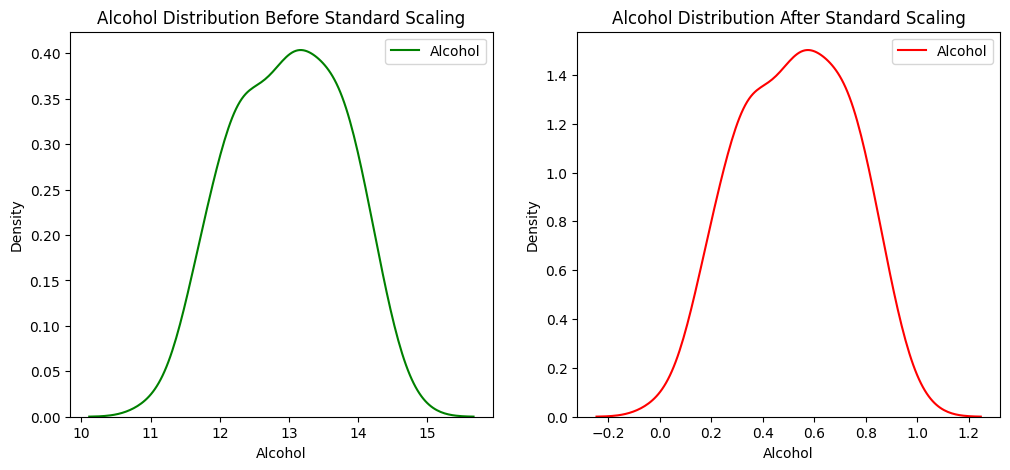

In [28]:
# Create a figure with two subplots side by side, with a specified size of 12x5 inches.
fig, (ax1, ax2) = plt.subplots(ncols=2, figsize=(12, 5))

# Set the title for the first subplot.
ax1.set_title("Alcohol Distribution Before Standard Scaling")

# Plot the KDE (Kernel Density Estimate) for 'Alcohol' in the original data.
sns.kdeplot(X_train['Alcohol'], ax=ax1, label='Alcohol', color='g')  # Added label for clarity
ax1.legend()  # Show legend for the first plot.

# Set the title for the second subplot.
ax2.set_title("Alcohol Distribution After Standard Scaling")

# Plot the KDE for 'Alcohol' in the scaled data.
sns.kdeplot(X_train_scaled['Alcohol'], ax=ax2, label='Alcohol', color='r')  # Added label and color for clarity
ax2.legend()  # Show legend for the second plot.

# Display the plots.
plt.show()

---